# **Laboratorio 10 - Visión por Computadora**

- Paula Barillas - 22764
- Gerardo Pineda - 22880
- Mónica Salvatierra - 22249

Link del repositorio: https://github.com/paulabaal12/LAB10-VCP

## **Task 1**

In [ ]:
#!pip install diffusers transformers accelerate torch torchvision Pillow

### Librerias

In [2]:
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from diffusers import StableDiffusionPipeline, DDIMScheduler
import warnings
warnings.filterwarnings("ignore")

c:\Users\ALEJANDRA\anaconda3\envs\gpu_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Scheduler y semilla

In [3]:
model_id = "runwayml/stable-diffusion-v1-5"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    safety_checker=None,
)
pipe = pipe.to("cuda")
pipe.enable_attention_slicing()

print("Modelo cargado en:", next(pipe.unet.parameters()).device)

Loading pipeline components...: 100%|██████████| 6/6 [00:06<00:00,  1.11s/it]
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


Modelo cargado en: cuda:0


In [4]:
pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)

SEED = 42
NUM_STEPS = 20
PROMPT = (
    "A highly detailed cinematic and futuristic fruit glowing in a cyberpunk laboratory, "
    "intricate geometric patterns on the surface, complex fractal textures, "
    "neon lights reflecting on metallic and glass materials, volumetric lighting, "
    "high contrast shadows, holographic elements, ultra sharp focus, 4k resolution, "
    "depth of field, dramatic composition, realistic reflections, subsurface scattering, "
    "sci-fi atmosphere"
)
NEGATIVE_PROMPT = "blurry, low quality, flat, plain, simple, dark, noisy"

CAPTURE_STEPS = {4, 10, 16, 20}

print(f"Seed: {SEED} | Steps: {NUM_STEPS} | Capturando en: {CAPTURE_STEPS}")

Seed: 42 | Steps: 20 | Capturando en: {16, 10, 4, 20}


In [5]:
generator = torch.manual_seed(SEED)

text_inputs = pipe.tokenizer(
    PROMPT,
    padding="max_length",
    max_length=pipe.tokenizer.model_max_length,
    truncation=True,
    return_tensors="pt",
)
text_embeddings = pipe.text_encoder(text_inputs.input_ids.to("cuda"))[0]

In [6]:
uncond_inputs = pipe.tokenizer(
    NEGATIVE_PROMPT,
    padding="max_length",
    max_length=pipe.tokenizer.model_max_length,
    truncation=True,
    return_tensors="pt",
)
uncond_embeddings = pipe.text_encoder(uncond_inputs.input_ids.to("cuda"))[0]

In [7]:
text_embeddings_cfg = torch.cat([uncond_embeddings, text_embeddings])

latents = torch.randn(
    (1, pipe.unet.config.in_channels, 64, 64),
    generator=generator,
    dtype=torch.float16,
).to("cuda")

pipe.scheduler.set_timesteps(NUM_STEPS)
latents = latents * pipe.scheduler.init_noise_sigma

In [8]:
captured_latents = {}

for i, t in enumerate(pipe.scheduler.timesteps):
    step_number = i + 1   # steps van de 1 a 20

    # se duplica el latente para CFG (uncond + cond)
    latent_input = torch.cat([latents] * 2)
    latent_input = pipe.scheduler.scale_model_input(latent_input, t)

    # predicción del ruido con U-Net
    with torch.no_grad():
        noise_pred = pipe.unet(latent_input, t, encoder_hidden_states=text_embeddings_cfg).sample

    # se separa la predicción uncondicionada y condicionada
    noise_pred_uncond, noise_pred_text = noise_pred.chunk(2)

    # se aplica Classifier-Free Guidance
    guidance_scale = 7.5
    noise_pred = noise_pred_uncond + guidance_scale * (noise_pred_text - noise_pred_uncond)

    # actualiza el latente
    latents = pipe.scheduler.step(noise_pred, t, latents).prev_sample
    
    if step_number in CAPTURE_STEPS:
        captured_latents[step_number] = latents.clone()
        print(f"Latente capturado en paso {step_number}")

print("\nCaptura completa. Pasos guardados:", sorted(captured_latents.keys()))

Latente capturado en paso 4
Latente capturado en paso 10
Latente capturado en paso 16
Latente capturado en paso 20

Captura completa. Pasos guardados: [4, 10, 16, 20]


In [9]:
def decode_latent(pipe, latent):
    scaling_factor = pipe.vae.config.scaling_factor
    latent_decoded = latent / scaling_factor

    with torch.no_grad():
        image_tensor = pipe.vae.decode(latent_decoded).sample   # shape: (1, 3, H, W)

    image_tensor = (image_tensor / 2 + 0.5).clamp(0, 1)
    image_np = image_tensor.squeeze(0).permute(1, 2, 0).cpu().float().numpy()
    image_pil = Image.fromarray((image_np * 255).astype(np.uint8))
    return image_pil


decoded_images = {}
for step, latent in sorted(captured_latents.items()):
    decoded_images[step] = decode_latent(pipe, latent)
    print(f"Imagen decodificada para paso {step}")

Imagen decodificada para paso 4
Imagen decodificada para paso 10
Imagen decodificada para paso 16
Imagen decodificada para paso 20


In [10]:
for step, img in decoded_images.items():
    filename = f"latent_step_{step:02d}.png"
    img.save(filename)
    print(f"Guardada: {filename}")

Guardada: latent_step_04.png
Guardada: latent_step_10.png
Guardada: latent_step_16.png
Guardada: latent_step_20.png


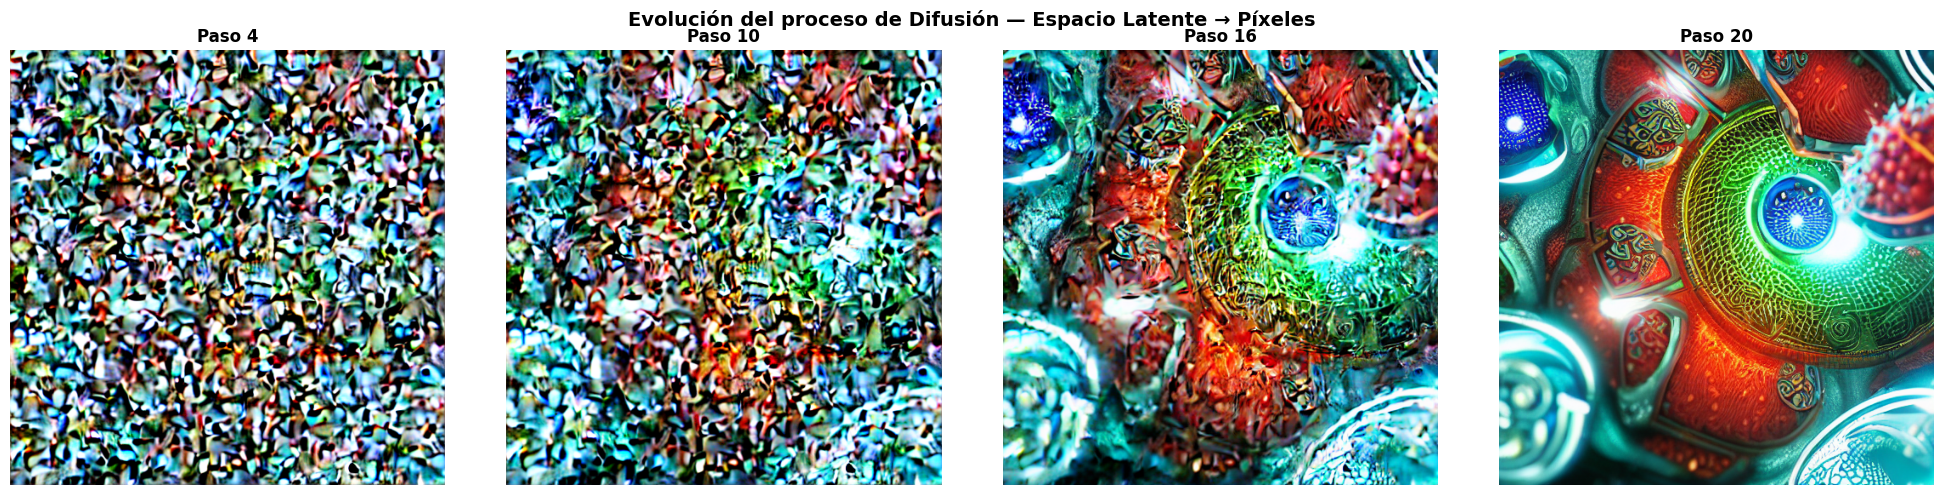

In [11]:
steps_to_show = sorted(decoded_images.keys())   # [4, 10, 16, 20]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle(
    "Evolución del proceso de Difusión — Espacio Latente → Píxeles",
    fontsize=14, fontweight="bold"
)

for ax, step in zip(axes, steps_to_show):
    ax.imshow(decoded_images[step])
    ax.set_title(f"Paso {step}", fontsize=12, fontweight="bold")
    ax.axis("off")

plt.tight_layout()
plt.savefig("evolucion_difusion.png", dpi=150, bbox_inches="tight")
plt.show()

**Observe la diferencia entre la imagen del paso 4 y la del paso 16. Explicado con base en la teoría de frecuencias espaciales y Cross-Attention: ¿Qué características de la imagen (forma global, colores bases, silueta vs. brillos, texturas finas, detalles del neón) resuelve la U-Net en las etapas iniciales de ruido alto, y qué resuelve en las etapas finales de ruido bajo? Justifique técnicamente su respuesta**

- En los pasos iniciales del proceso de denoising, específicamente en el paso 4, el nivel de ruido presente en el espacio latente es aún muy elevado. En esta etapa, la U-Net opera principalmente sobre frecuencias espaciales bajas, definiendo la estructura compositiva global de la imagen, como la distribución de masas de color, la posición aproximada del objeto principal y la paleta cromática general. El mecanismo de Cross-Attention con el prompt textual guía este proceso, estableciendo desde temprano la "intención" de la imagen, aunque visualmente el resultado todavía se ve como ruido caótico con bloques de color poco definidos.

    Conforme el proceso avanza hacia el paso 16, el nivel de ruido residual disminuye considerablemente, permitiéndole a la U-Net enfocarse en frecuencias espaciales más altas. Es en esta etapa es donde emergen los detalles finos que caracterizan la imagen final, como las texturas geométricas sobre la superficie de la fruta, los reflejos de luz neón, los contrastes de sombra y los elementos holográficos descritos en el prompt. El Cross-Attention en estas capas más profundas refina atributos específicos que requieren mayor resolución semántica para ser representados correctamente.

    En conclusión, las etapas iniciales del proceso se encargan de resolver la composición global y la paleta de color, mientras que las etapas finales se dedican a construir la coherencia visual y el detalle de alta frecuencia. Este comportamiento es consistente con el diseño del scheduler DDIM, que distribuye el trabajo de denoising, de manera que los cambios estructurales grandes ocurran primero y los refinamientos detallados al final.

### **Prompt Utilizado**

**Uso de ChatGPT**

**Task 1**

Estoy trabajando con la librería diffusers de Hugging Face en Python y tengo dudas puntuales sobre el pipeline de Stable Diffusion. Explícame brevemente: cómo interceptar el tensor latente durante el loop de denoising sin reescribir el pipeline desde cero (usando callback_on_step_end o el ciclo scheduler.step() manualmente), por qué debo dividir el latente por el scaling_factor del VAE antes de llamar a vae.decode() y cómo convertir la salida del VAE de rango [-1, 1] a una imagen PIL. Dame ejemplos cortos y directos para cada punto.

### **Por qué funcionó este prompt**

Funcionó porque especificó componentes concretos de la arquitectura (VAE, scheduler, loop de denoising) en lugar de pedir "cómo generar una imagen", lo que forzó respuestas enfocadas en la manipulación interna de tensores.  Incluir las dos alternativas de interceptación (callback vs loop manual) permitió comparar ambos enfoques y elegir el más adecuado para el nivel de control requerido.